# Gradient Descent in 1D

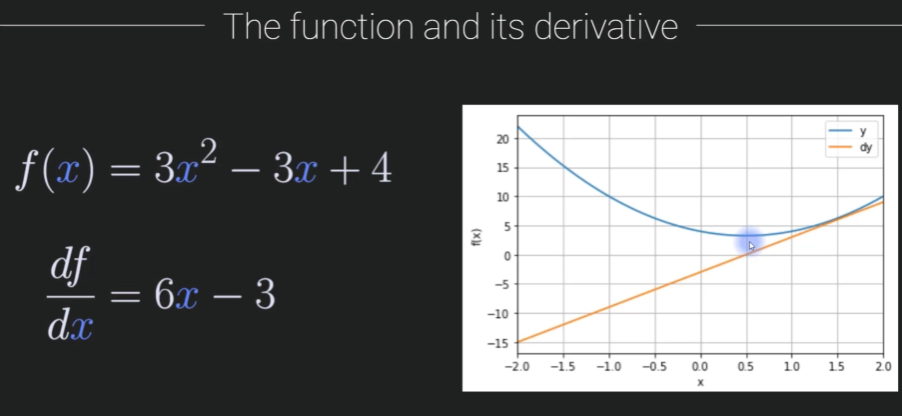

### Python Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'png') 

In [44]:
# function ( as a function) as well as its derivative
def f(x):
    return 3*x**2 - 3*x + 4
def deriv(x):
    return 6*x - 3
x = np.linspace(-2, 2, 2001)

In [143]:
x

array([-2.   , -1.998, -1.996, ...,  1.996,  1.998,  2.   ], shape=(2001,))

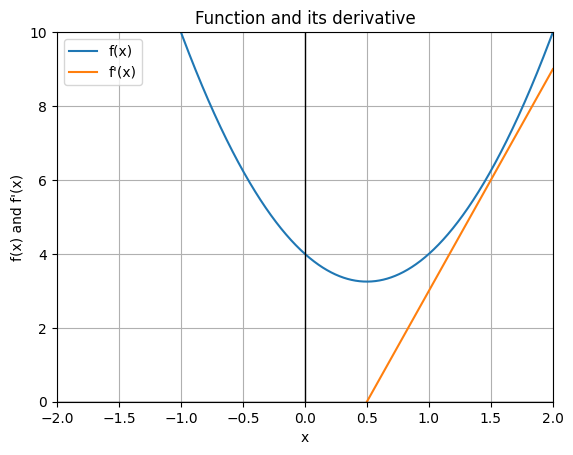

In [45]:
# plot the function and its derivative
plt.plot(x, f(x))
plt.plot(x, deriv(x))
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlim(-2, 2)
plt.ylim(0, 10)
plt.xlabel('x')
plt.ylabel('f(x) and f\'(x)')
plt.title('Function and its derivative')
plt.legend(['f(x)', 'f\'(x)'])
plt.grid()
plt.show()

In [48]:
# gradient descent

#randomly select a point on the x-axis
localmin = np.random.choice(x, 1)
print(f'initial point: {localmin}')
# learning parameters
learning_rate = 0.01
training_epochs = 100

# run through training steps
for step in range(training_epochs):
    # compute the gradient at the current point
    grad = deriv(localmin)
    
    # update the point using the gradient and learning rate
    localmin = localmin - learning_rate * grad

localmin


initial point: [-1.97]


array([0.49492446])

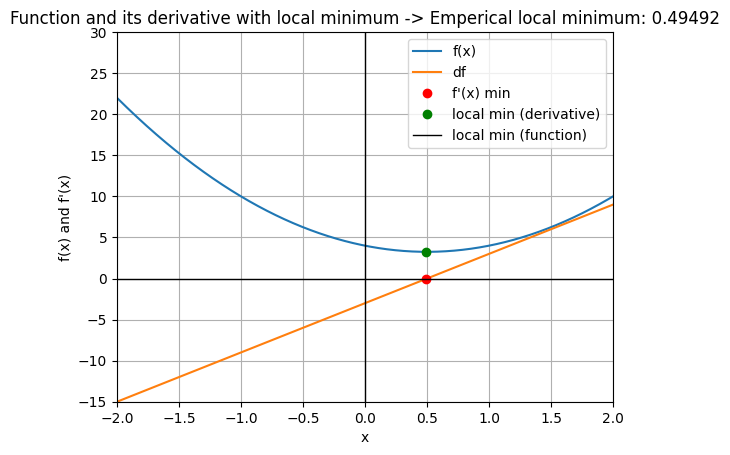

In [58]:
# plot the results
plt.plot(x, f(x), x, deriv(x))
plt.plot(localmin, deriv(localmin), 'ro')
plt.plot(localmin, f(localmin), 'go')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlim(-2, 2)
plt.ylim(-15, 30)
plt.xlabel('x')
plt.ylabel('f(x) and f\'(x)')
plt.title('Function and its derivative with local minimum -> Emperical local minimum: %.5f'%localmin[0])
plt.legend(['f(x)','df', 'f\'(x) min', 'local min (derivative)', 'local min (function)'])
plt.grid()
plt.show()  

In [125]:
# Store the model parameters and outputs on each iteration

# random starting point
localmin = np.random.choice(x, 1)
print(f'initial point: {localmin}')

# learning parameters
learning_rate = 0.01
training_epochs = 100

# run through training steps and store the model parameters and outputs on each iteration
modelparams = np.zeros((training_epochs, 2)) # columns for localmin, f(localmin), deriv(localmin)

for step in range(training_epochs):
    grad = deriv(localmin)
    localmin = localmin - learning_rate * grad  
    modelparams[step, :] = localmin[0], grad[0]


initial point: [0.994]


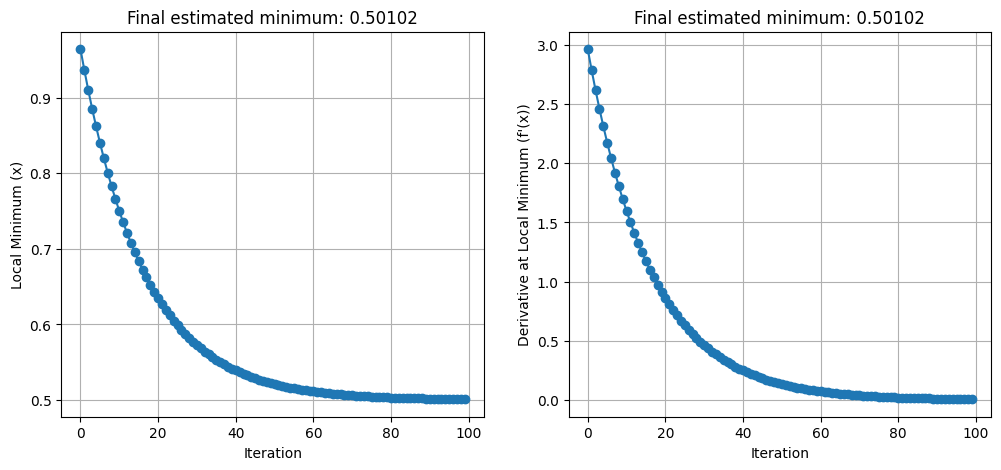

In [126]:
# plot the gradient descent over iterations
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i in range(2):
    ax[i].plot(modelparams[:, i], marker='o')
    ax[i].set_xlabel('Iteration')
    ax[i].set_title('Final estimated minimum: %.5f'%localmin[0])
    
ax[0].set_ylabel('Local Minimum (x)')
ax[1].set_ylabel('Derivative at Local Minimum (f\'(x))')
ax[0].grid()
ax[1].grid()
plt.show() 


### Additional explorations

In [127]:
# 1) Modify the code so that training ends when the derivative is smaller than some threshold (e.g., 0.01) instead of a fixed number of epochs. Make sure the code is robust for negative derivates.

# random starting point
localmin = np.random.choice(x,1)
grad_threshold = 0.001
grad = deriv(localmin)

xi = np.array([localmin, grad])


while np.abs(grad) > grad_threshold:
    localmin = localmin - learning_rate * grad
    grad = deriv(localmin)
    xi = np.append(xi,[localmin, grad]) 

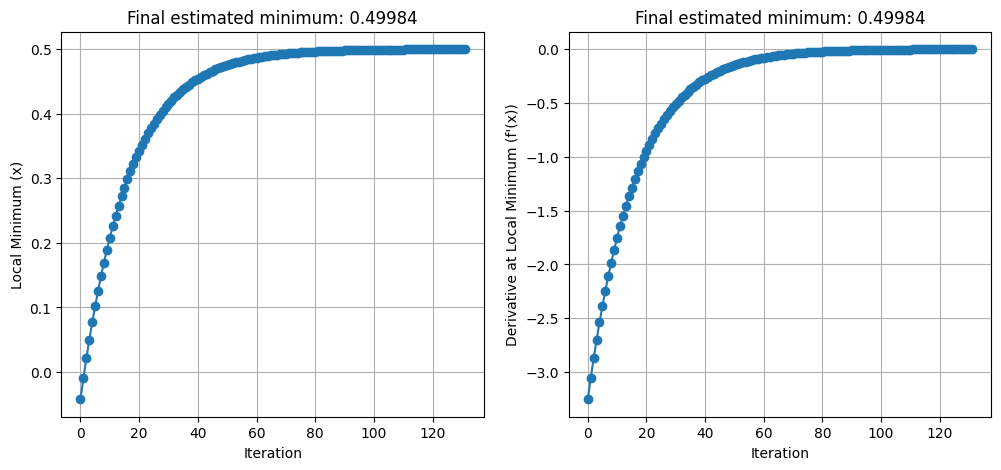

In [129]:
# plot the gradient descent over iterations
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
iterations = np.arange(len(xi) // 2)
ax[0].plot(iterations, xi[0::2], marker='o')
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('Local Minimum (x)')
ax[0].set_title('Final estimated minimum: %.5f'%localmin[0])
ax[1].plot(iterations, xi[1::2], marker='o')
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('Derivative at Local Minimum (f\'(x))')
ax[1].set_title('Final estimated minimum: %.5f'%localmin[0])
ax[0].grid()
ax[1].grid()
plt.show()

In [141]:
# 2) no it does not 

In [142]:
# 3) with the gradient stopping criterion, gradient descent can stuck in local minima, due to vanishing gradients, be affected by exploding gradients, infinite runs due to slow learning progress